In [ ]:
# 1 Uploading the dataset

from google.colab import files

uploaded = files.upload()

Saving company_employee_details5000.csv to company_employee_details5000.csv


In [ ]:
# 2 Import all essential libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# 3 Load dataset into dataframe

df = pd.read_csv("company_employee_details5000.csv")

# Display first 5 rows
df.head()

,employee_id,company,department,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,Gender,Resting_Heart_Rate
0,16,Glasses,BigData,41,38,3,68074.97135,17664.10410,3,Male,81.2
1,56,Glasses,AI,44,42,2,49092.14746,21551.14108,2,Male,75.8
2,59,Cheerper,Support,41,40,1,40000.00000,23698.87885,2,Female,72.4
3,40,Glasses,Design,39,32,7,108192.46550,21570.92966,1,Male,65.6
4,47,Glasses,Search Engine,30,22,9,71291.19113,21565.50572,2,Male,73.9


In [ ]:
# 4 Check dataset shape (rows, columns)

df.shape

(5000, 11)

In [ ]:
# 5 Display all column names

df.columns

Index(['employee_id', 'company', 'department', 'age', 'age_when_joined',
       'years_in_the_company', 'salary', 'annual_bonus',
       'prior_years_experience', 'Gender', 'Resting_Heart_Rate'],
      dtype='object')

In [ ]:
# 6 Dataset information (data types and null counts)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             5000 non-null   int64  
 1   company                 5000 non-null   object 
 2   department              5000 non-null   object 
 3   age                     5000 non-null   int64  
 4   age_when_joined         5000 non-null   int64  
 5   years_in_the_company    5000 non-null   int64  
 6   salary                  5000 non-null   float64
 7   annual_bonus            5000 non-null   float64
 8   prior_years_experience  5000 non-null   int64  
 9   Gender                  5000 non-null   object 
 10  Resting_Heart_Rate      5000 non-null   float64
dtypes: float64(3), int64(5), object(3)
memory usage: 429.8+ KB


In [ ]:
# 7 Check for missing values (0 means no missing values)

df.isnull().sum()

,0
employee_id,0
company,0
department,0
age,0
age_when_joined,0
years_in_the_company,0
salary,0
annual_bonus,0
prior_years_experience,0
Gender,0


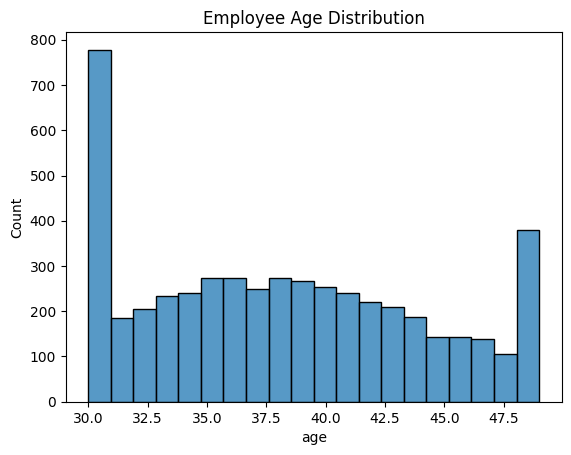

In [ ]:
# 8 Plot age distribution

sns.histplot(df["age"], bins=20)
plt.title("Employee Age Distribution")
plt.show()

In [ ]:
# 9 Count of female and male employees

df["Gender"].value_counts()

,count
Gender,
Male,2600
Female,2400


In [ ]:
# 10 Resting heart rate statistics

df["Resting_Heart_Rate"].describe()

,Resting_Heart_Rate
count,5000.000000
mean,71.994900
std,5.020949
min,55.000000
25%,68.600000
50%,72.000000
75%,75.425000
max,92.200000


In [ ]:
# 11 Create Workload Score (normalized years in company, scaled 0-10)
# Scale years to a 0-10 range

max_years = df["years_in_the_company"].max()
df["Workload_Score"] = (df["years_in_the_company"] / max_years) * 10
df["Workload_Score"] = df["Workload_Score"].round(2)

df[["years_in_the_company", "Workload_Score"]].head()

,years_in_the_company,Workload_Score
0,3,3.33
1,2,2.22
2,1,1.11
3,7,7.78
4,9,10.00


In [ ]:
# 12 Create Experience Pressure (clip negatives to 0)

df["Experience_Pressure"] = (df["years_in_the_company"] - df["prior_years_experience"]).clip(lower=0)

df[["Experience_Pressure"]].head()

,Experience_Pressure
0,0
1,0
2,0
3,6
4,7


In [ ]:
# 13 Normalize resting heart rate to a 0-10 stress indicator

hr_min = df["Resting_Heart_Rate"].min()
hr_max = df["Resting_Heart_Rate"].max()

df["HeartRate_Stress"] = ((df["Resting_Heart_Rate"] - hr_min) / (hr_max - hr_min)) * 10
df["HeartRate_Stress"] = df["HeartRate_Stress"].round(2)

df[["HeartRate_Stress"]].head()

,HeartRate_Stress
0,7.04
1,5.59
2,4.68
3,2.85
4,5.08


In [ ]:
# 14 Calculate Stress Score (weighted combination of stress indicators)

df["Stress_Score"] = (
    df["Workload_Score"] * 0.4 +
    df["Experience_Pressure"] * 0.3 +
    df["HeartRate_Stress"] * 0.3
)
df["Stress_Score"] = df["Stress_Score"].round(2)

df[["Stress_Score"]].head()

,Stress_Score
0,3.44
1,2.56
2,1.85
3,5.77
4,7.62


In [ ]:
# 15 Convert Stress Score to Stress Level (Low / Medium / High)

def classify_stress(score):
    if score < 3:
        return "Low"
    elif score < 6:
        return "Medium"
    else:
        return "High"

df["Stress_Level"] = df["Stress_Score"].apply(classify_stress)

df["Stress_Level"].value_counts()

,count
Stress_Level,
Medium,2343
Low,1611
High,1046


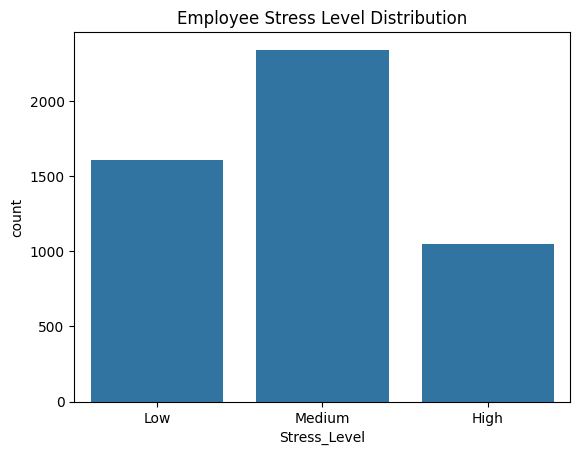

In [ ]:
# 16 Plot stress level distribution (using string labels before encoding)

sns.countplot(x="Stress_Level", data=df, order=["Low", "Medium", "High"])
plt.title("Employee Stress Level Distribution")
plt.show()

In [ ]:
# 17 Encode Stress_Level to numeric: Low=0, Medium=1, High=2

df["Stress_Level"] = df["Stress_Level"].map({"Low": 0, "Medium": 1, "High": 2})
df["Stress_Level"].value_counts()

,count
Stress_Level,
1,2343
0,1611
2,1046


In [ ]:
# 18 Encode Gender to numeric: Male=0, Female=1

df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df["Gender"].value_counts()

,count
Gender,
0,2600
1,2400


In [ ]:
# 19 One-hot encode categorical columns: company, department

df = pd.get_dummies(df, columns=["company", "department"], drop_first=True)
df.head()

,employee_id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,Gender,Resting_Heart_Rate,Workload_Score,...,HeartRate_Stress,Stress_Score,Stress_Level,company_Glasses,company_Pear,department_BigData,department_Design,department_Sales,department_Search Engine,department_Support
0,16,41,38,3,68074.97135,17664.10410,3,0,81.2,3.33,...,7.04,3.44,1,True,False,True,False,False,False,False
1,56,44,42,2,49092.14746,21551.14108,2,0,75.8,2.22,...,5.59,2.56,0,True,False,False,False,False,False,False
2,59,41,40,1,40000.00000,23698.87885,2,1,72.4,1.11,...,4.68,1.85,0,False,False,False,False,False,False,True
3,40,39,32,7,108192.46550,21570.92966,1,0,65.6,7.78,...,2.85,5.77,1,True,False,False,True,False,False,False
4,47,30,22,9,71291.19113,21565.50572,2,0,73.9,10.00,...,5.08,7.62,2,True,False,False,False,False,True,False


In [ ]:
# 20 Create feature matrix X and target variable y

leak_cols = [
    "Stress_Level", "Stress_Score",
    "Workload_Score", "Experience_Pressure", "HeartRate_Stress",
    "employee_id"
]

X = df.drop([c for c in leak_cols if c in df.columns], axis=1)
y = df["Stress_Level"]

print("Features used:", list(X.columns))
print("Feature matrix shape:", X.shape)

Features used: ['age', 'age_when_joined', 'years_in_the_company', 'salary', 'annual_bonus', 'prior_years_experience', 'Gender', 'Resting_Heart_Rate', 'company_Glasses', 'company_Pear', 'department_BigData', 'department_Design', 'department_Sales', 'department_Search Engine', 'department_Support']
Feature matrix shape: (5000, 15)


In [ ]:
# 21 Split dataset into training (80%) and testing (20%) sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (4000, 15)
Testing Size: (1000, 15)


In [ ]:
# 22 Check class distribution in training set (should be balanced)

y_train.value_counts()

,count
Stress_Level,
1,1874
0,1289
2,837


In [ ]:
# 23 Scale features for Logistic Regression and SVM

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


In [ ]:
# 24 Train all models

# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

# --- Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

# --- SVM ---
svm_model = SVC(C=1, kernel='rbf', gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("All models trained successfully")

All models trained successfully


In [ ]:
# 25 Model accuracy on test data

y_pred_lr  = lr_model.predict(X_test_scaled)
y_pred_dt  = dt_model.predict(X_test)
y_pred_rf  = rf_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test_scaled)

models_list = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
test_preds  = [y_pred_lr, y_pred_dt, y_pred_rf, y_pred_svm]

print("===== MODEL ACCURACY =====")
for name, pred in zip(models_list, test_preds):
    print(f"{name:<22}: {accuracy_score(y_test, pred):.3f}")

===== MODEL ACCURACY =====
Logistic Regression   : 0.979
Decision Tree         : 0.984
Random Forest         : 0.938
SVM                   : 0.965


In [ ]:
# 26 Detailed classification report for each model

for name, pred in zip(models_list, test_preds):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print('='*45)
    print(classification_report(y_test, pred, target_names=["Low", "Medium", "High"]))


  Logistic Regression
              precision    recall  f1-score   support

         Low       0.96      0.99      0.98       322
      Medium       0.98      0.97      0.98       469
        High       1.00      0.98      0.99       209

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


  Decision Tree
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       322
      Medium       0.98      0.99      0.98       469
        High       0.98      0.97      0.97       209

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


  Random Forest
              precision    recall  f1-score   support

         Low       0.96      0.93      0.94       322
      Medium       0.92      0.95      0.94       469
        High      

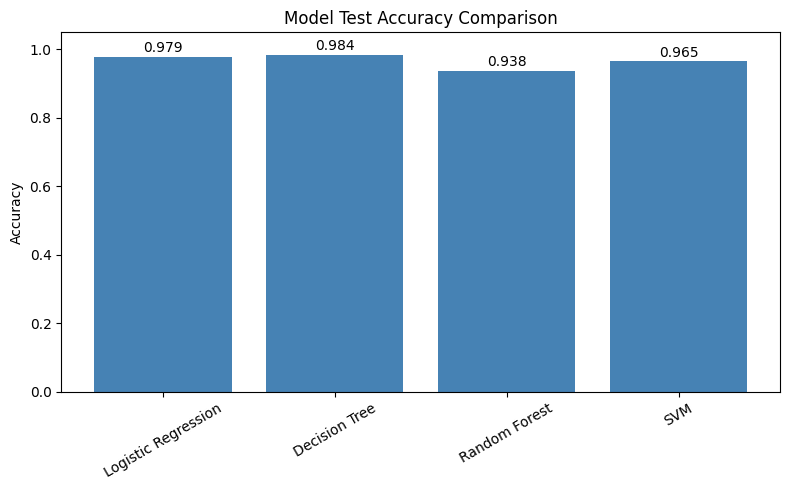

In [ ]:
# 27 Plot model accuracy comparison (test accuracy)

test_accuracies = [accuracy_score(y_test, p) for p in test_preds]

plt.figure(figsize=(8, 5))
bars = plt.bar(models_list, test_accuracies, color='steelblue')
plt.title("Model Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1.05)

for bar, acc in zip(bars, test_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.3f}",
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# 28 Automatically identify the best model from comparison

best_idx = test_accuracies.index(max(test_accuracies))
best_model_name = models_list[best_idx]
best_pred = test_preds[best_idx]

# Determine if best model uses scaled or unscaled features
scaled_models = ["Logistic Regression", "SVM"]
best_uses_scaled = best_model_name in scaled_models

# Set the best model object
model_objects = [lr_model, dt_model, rf_model, svm_model]
best_model = model_objects[best_idx]

# Set the correct test input for the best model
X_test_best = X_test_scaled if best_uses_scaled else X_test
X_train_best = X_train_scaled if best_uses_scaled else X_train

print(f"Best Model   : {best_model_name}")
print(f"Best Accuracy: {max(test_accuracies):.3f}")

Best Model   : Decision Tree
Best Accuracy: 0.984


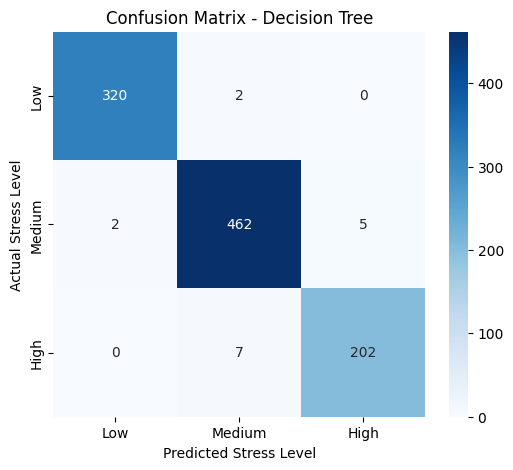

In [ ]:
# 29 Confusion Matrix for the best model

cm_best = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Stress Level")
plt.ylabel("Actual Stress Level")
plt.show()

In [ ]:
# 30 Detailed classification report for the best model

print(f"\n{'='*45}")
print(f"  Classification Report - {best_model_name}")
print('='*45)
print(classification_report(y_test, best_pred, target_names=["Low", "Medium", "High"]))


  Classification Report - Decision Tree
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       322
      Medium       0.98      0.99      0.98       469
        High       0.98      0.97      0.97       209

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



In [ ]:
# 31 Train all models (re-included for self-containment)
# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, C=0.5, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

# --- Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

# --- SVM ---
svm_model = SVC(C=1, kernel='rbf', gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_lr_train  = lr_model.predict(X_train_scaled)
y_pred_dt_train  = dt_model.predict(X_train)
y_pred_rf_train  = rf_model.predict(X_train)
y_pred_svm_train = svm_model.predict(X_train_scaled)

models_list = ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
train_preds  = [y_pred_lr_train, y_pred_dt_train, y_pred_rf_train, y_pred_svm_train]

print("===== MODEL TRAINING ACCURACY ====")
for name, pred in zip(models_list, train_preds):
    print(f"{name:<22}: {accuracy_score(y_train, pred):.3f}")

===== MODEL TRAINING ACCURACY ====
Logistic Regression   : 0.982
Decision Tree         : 0.993
Random Forest         : 0.970
SVM                   : 0.980


Top 5 Features - Decision Tree
years_in_the_company        0.789387
Resting_Heart_Rate          0.130014
prior_years_experience      0.074593
annual_bonus                0.003850
department_Search Engine    0.000983
dtype: float64


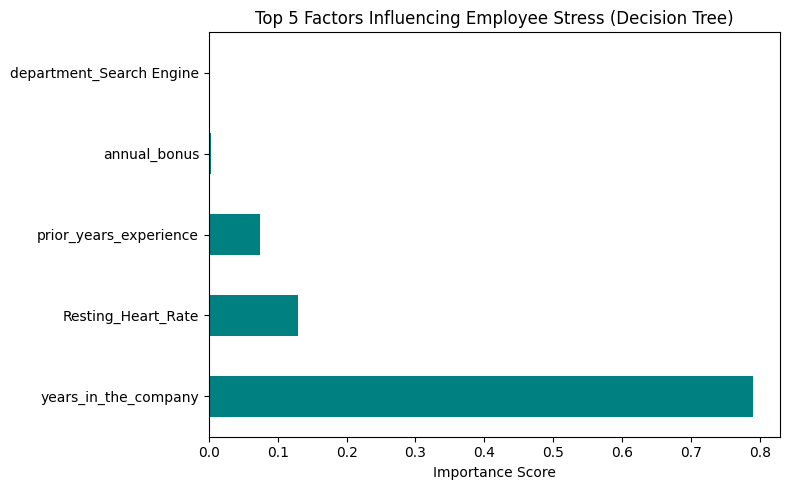

In [ ]:
# 32 Feature importance for the best model (if supported)

if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print(f"Top 5 Features - {best_model_name}")
    print(feature_importance.head(5))

    feature_importance.head(5).plot(kind="barh", figsize=(8, 5), color='teal')
    plt.title(f"Top 5 Factors Influencing Employee Stress ({best_model_name})")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, "coef_"):
    # Logistic Regression - use absolute coefficient values
    importance = pd.Series(
        np.abs(best_model.coef_).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=False)

    print(f"Top 5 Features - {best_model_name} (by coefficient magnitude)")
    print(importance.head(5))

    importance.head(5).plot(kind="barh", figsize=(8, 5), color='steelblue')
    plt.title(f"Top 5 Factors Influencing Employee Stress ({best_model_name})")
    plt.xlabel("Mean |Coefficient|")
    plt.tight_layout()
    plt.show()

else:
    print(f"{best_model_name} does not directly expose feature importance.")
    print("Showing feature importance from Decision Tree as reference.")

    feature_importance = pd.Series(
        dt_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    print(feature_importance.head(5))
    feature_importance.head(5).plot(kind="barh", figsize=(8, 5), color='teal')
    plt.title("Top 5 Factors Influencing Employee Stress (Decision Tree Reference)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

In [ ]:
# 33 Cross-Validation Accuracy (5-fold) for the best model

cv_best = cross_val_score(best_model, X_train_best, y_train, cv=5, scoring='accuracy')

print(f"===== CROSS-VALIDATION ACCURACY - {best_model_name} =====")
print(f"Fold Scores : {np.round(cv_best, 4)}")
print(f"Mean        : {np.mean(cv_best):.4f}")
print(f"Std Dev     : {np.std(cv_best):.4f}")


===== CROSS-VALIDATION ACCURACY - Decision Tree =====
Fold Scores : [0.9812 0.9775 0.9775 0.99   0.9762]
Mean        : 0.9805
Std Dev     : 0.0050


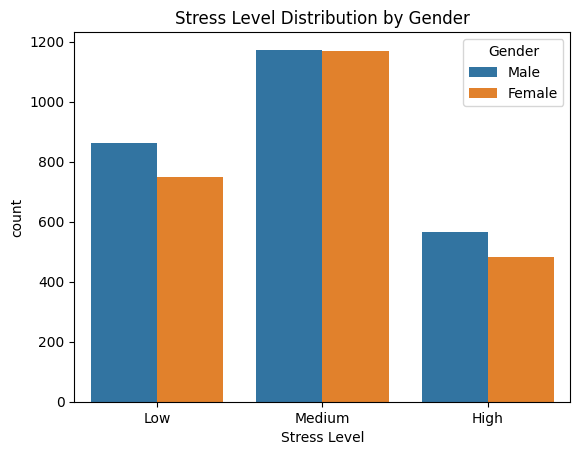

In [ ]:
# 34 Gender vs Stress distribution

gender_labels = {0: "Male", 1: "Female"}
stress_labels = {0: "Low", 1: "Medium", 2: "High"}

plot_df = df.copy()
plot_df["Gender_Label"] = plot_df["Gender"].map(gender_labels)
plot_df["Stress_Label"] = plot_df["Stress_Level"].map(stress_labels)

sns.countplot(
    x="Stress_Label",
    hue="Gender_Label",
    data=plot_df,
    order=["Low", "Medium", "High"]
)
plt.title("Stress Level Distribution by Gender")
plt.xlabel("Stress Level")
plt.legend(title="Gender")
plt.show()

In [ ]:
# 35 Train gender-specific models using the best algorithm

from sklearn.base import clone

# --- Male ---
male_df  = df[df["Gender"] == 0]
X_male   = male_df.drop([c for c in leak_cols if c in male_df.columns], axis=1)
y_male   = male_df["Stress_Level"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_male, y_male, test_size=0.2, random_state=42, stratify=y_male
)

# --- Female ---
female_df  = df[df["Gender"] == 1]
X_female   = female_df.drop([c for c in leak_cols if c in female_df.columns], axis=1)
y_female   = female_df["Stress_Level"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_female, y_female, test_size=0.2, random_state=42, stratify=y_female
)

# Scale if needed
if best_uses_scaled:
    scaler_m = StandardScaler()
    X_train_m_fit = scaler_m.fit_transform(X_train_m)
    X_test_m_fit  = scaler_m.transform(X_test_m)

    scaler_f = StandardScaler()
    X_train_f_fit = scaler_f.fit_transform(X_train_f)
    X_test_f_fit  = scaler_f.transform(X_test_f)
else:
    X_train_m_fit, X_test_m_fit = X_train_m, X_test_m
    X_train_f_fit, X_test_f_fit = X_train_f, X_test_f

# Clone and train gender-specific models
best_model_male   = clone(best_model)
best_model_female = clone(best_model)

best_model_male.fit(X_train_m_fit, y_train_m)
best_model_female.fit(X_train_f_fit, y_train_f)

y_pred_male   = best_model_male.predict(X_test_m_fit)
y_pred_female = best_model_female.predict(X_test_f_fit)

print(f"Best Model Used         : {best_model_name}")
print(f"Global Model Accuracy   : {round(accuracy_score(y_test, best_pred), 3)}")
print(f"Male Model Accuracy     : {round(accuracy_score(y_test_m, y_pred_male), 3)}")
print(f"Female Model Accuracy   : {round(accuracy_score(y_test_f, y_pred_female), 3)}")

Best Model Used         : Decision Tree
Global Model Accuracy   : 0.984
Male Model Accuracy     : 0.977
Female Model Accuracy   : 0.971


In [ ]:
# 5Manual Input for Stress Prediction using the best model

print(f"Enter employee details for stress prediction (Model: {best_model_name})")

age              = int(input("Enter Age: "))
gender           = int(input("Gender (Male=0, Female=1): "))
years_company    = int(input("Years in company: "))
prior_exp        = int(input("Prior years experience: "))
salary           = float(input("Enter Salary: "))
annual_bonus     = float(input("Enter Annual Bonus: "))
heart_rate       = float(input("Resting Heart Rate: "))
company_input    = input("Enter Company (e.g., Glasses, Cheerper, Pear): ")
department_input = input("Enter Department (e.g., BigData, AI, Support, Design, Sales, Search Engine): ")

age_when_joined = max(age - years_company, 18)

manual_input_data = {
    'age':                    age,
    'age_when_joined':        age_when_joined,
    'years_in_the_company':   years_company,
    'salary':                 salary,
    'annual_bonus':           annual_bonus,
    'prior_years_experience': prior_exp,
    'Gender':                 gender,
    'Resting_Heart_Rate':     heart_rate,
}

for col in X.columns:
    if col.startswith('company_') or col.startswith('department_'):
        manual_input_data[col] = False

if f'company_{company_input}' in X.columns:
    manual_input_data[f'company_{company_input}'] = True
else:
    print(f"Warning: company '{company_input}' not found. Using default encoding.")

if f'department_{department_input}' in X.columns:
    manual_input_data[f'department_{department_input}'] = True
else:
    print(f"Warning: department '{department_input}' not found. Using default encoding.")

manual_df = pd.DataFrame([manual_input_data], columns=X.columns)

# Apply scaling if the best model requires it
if best_uses_scaled:
    manual_input_scaled = scaler.transform(manual_df)
    prediction = best_model.predict(manual_input_scaled)
else:
    prediction = best_model.predict(manual_df)

stress_map = {0: "Low", 1: "Medium", 2: "High"}

print("\n--- Prediction Result ---")
print(f"Model Used            : {best_model_name}")
print(f"Predicted Stress Level: {stress_map[prediction[0]]}")
print(f"Employee Gender       : {'Male' if gender == 0 else 'Female'}")

Enter employee details for stress prediction (Model: Decision Tree)
Enter Age: 45
Gender (Male=0, Female=1): 0
Years in company: 20
Prior years experience: 1
Enter Salary: 40000
Enter Annual Bonus: 00
Resting Heart Rate: 95
Enter Company (e.g., Glasses, Cheerper, Pear): Cheerper
Enter Department (e.g., BigData, AI, Support, Design, Sales, Search Engine): Support

--- Prediction Result ---
Model Used            : Decision Tree
Predicted Stress Level: High
Employee Gender       : Male
